# Plotting with pandas and seaborn

matplotlib is fairly low-level: you assemble a plot from its base components — the data display (the plot type: line, bar, box, scatter, contour, etc.), legend, title, tick labels, and other annotations.

pandas objects often carry multiple columns of data along with row and column labels, so pandas itself has built-in methods that simplify creating visualizations directly from `Series` and `DataFrame` objects. **seaborn** is a higher-level statistical graphics library built on top of matplotlib that makes many common statistical visualizations (aggregations, regressions, distributions) much easier to produce.

> **Rule of thumb:** reach for pandas' built-in `.plot()` for quick, exploratory looks at your data. Reach for seaborn when the plot requires aggregation/summarization (means, counts, confidence intervals) or when you're comparing across categorical groups.

## Line Plots

`Series` and `DataFrame` both have a `.plot` accessor for making common plot types. By default, `.plot()` produces a line plot.

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 

<Axes: >

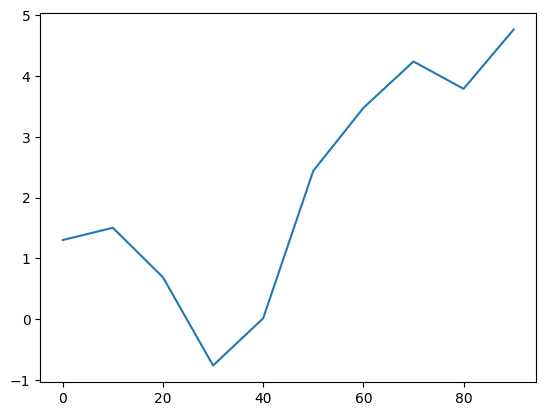

In [2]:
s = pd.Series(np.random.standard_normal(10).cumsum(), index=np.arange(0, 100, 10))

s.plot()

The `Series` object's index is passed to matplotlib for plotting on the x-axis, though this can be disabled by passing `use_index=False`. The x-axis ticks and limits can be adjusted with the `xticks`/`xlim` options, and the y-axis with `yticks`/`ylim`.

**Common `.plot()` keyword arguments:**

| Argument | Description |
|---|---|
| `label` | Text label for the plot's legend |
| `ax` | The matplotlib subplot object to draw on; if omitted, uses the current active subplot |
| `style` | Style string shorthand passed to matplotlib, e.g. `"ko--"` for a black dashed line with circle markers |
| `alpha` | Plot fill opacity, from 0 (fully transparent) to 1 (fully opaque) |
| `kind` | Type of plot to generate: `"line"`, `"bar"`, `"barh"`, `"hist"`, `"box"`, `"kde"`/`"density"`, `"area"`, `"pie"`, `"scatter"` (DataFrame only), `"hexbin"` (DataFrame only) |
| `logy` | Apply a log scale to the y-axis |
| `use_index` | Use the object's index for tick labels on the x-axis |
| `rot` | Rotation angle for tick labels (0 through 360) |
| `xticks` | Values to use for x-axis ticks |
| `yticks` | Values to use for y-axis ticks |
| `xlim` | x-axis limits, e.g. `[0, 10]` |
| `ylim` | y-axis limits |
| `grid` | Show axis gridlines (on by default) |

`DataFrame.plot()` plots each column as a separate line on the same subplot, creating a legend automatically:

<Axes: >

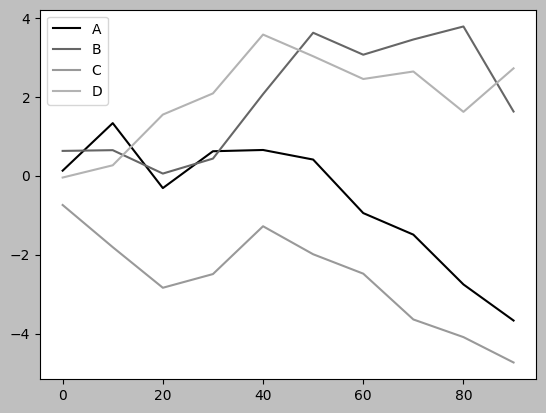

In [3]:
df = pd.DataFrame(np.random.standard_normal((10, 4)).cumsum(0), columns=["A", "B", "C", "D"], index=np.arange(0, 100, 10))

plt.style.use('grayscale')

df.plot()

The `.plot` accessor is a "family" of methods for different plot types — `df.plot()` is equivalent to `df.plot.line()`. We'll explore some of these next.

`DataFrame.plot()` also has options for how columns are handled — for example, whether to plot them all on the same subplot or split into separate subplots:

| Argument | Description |
|---|---|
| `subplots` | Plot each DataFrame column in a separate subplot |
| `layout` | 2-tuple `(rows, columns)` giving the layout of subplots |
| `sharex` | If `subplots=True`, share the same x-axis, linking ticks and limits |
| `sharey` | If `subplots=True`, share the same y-axis |
| `legend` | Add a subplot legend (`True` by default) |
| `sort_columns` | Plot columns in alphabetical order; by default uses existing column order |

## Bar Plots

`plot.bar()` and `plot.barh()` make vertical and horizontal bar plots, respectively. The `Series` or `DataFrame` index is used as the `x` (bar) or `y` (barh) tick labels.

<Axes: >

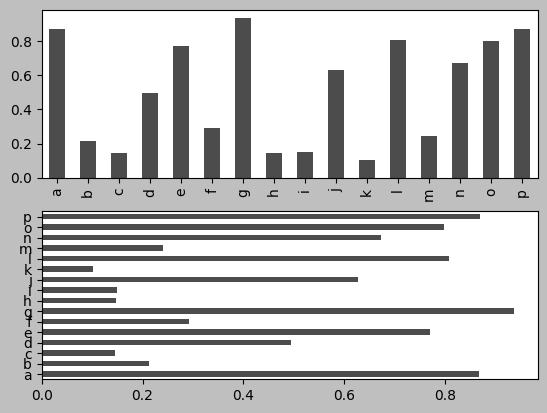

In [4]:
fig, axes = plt.subplots(2, 1)

data = pd.Series(np.random.uniform(size=16), index=list("abcdefghijklmnop"))

data.plot.bar(ax=axes[0], color="black", alpha=0.7)
data.plot.barh(ax=axes[1], color="black", alpha=0.7)

With a DataFrame, bar plots group the values in each row into bars side by side — one bar per column, clustered by row.

In [5]:
df = pd.DataFrame(np.random.uniform(size=(6, 4)),
                index=["one", "two", "three", "four", "five", "six"],
                columns=pd.Index(["A", "B", "C", "D"], name="Genus"))

df

Genus,A,B,C,D
one,0.100186,0.981305,0.294818,0.415575
two,0.357236,0.048706,0.633531,0.803270
three,0.697010,0.706729,0.812460,0.303125
four,0.558225,0.739663,0.124161,0.711261
five,0.471262,0.753168,0.967613,0.836806
six,0.188260,0.546938,0.781643,0.321675


<Axes: >

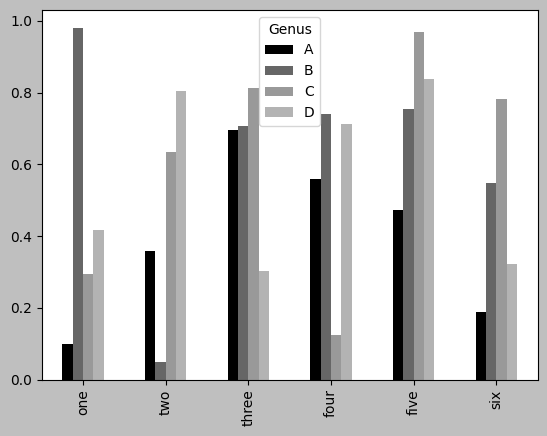

In [6]:
df.plot.bar()

**Note:** the name `"Genus"` on the DataFrame's columns is used to title the legend.

Create stacked bar plots from a DataFrame by passing `stacked=True` — the values in each row are stacked together instead of placed side by side:

<Axes: >

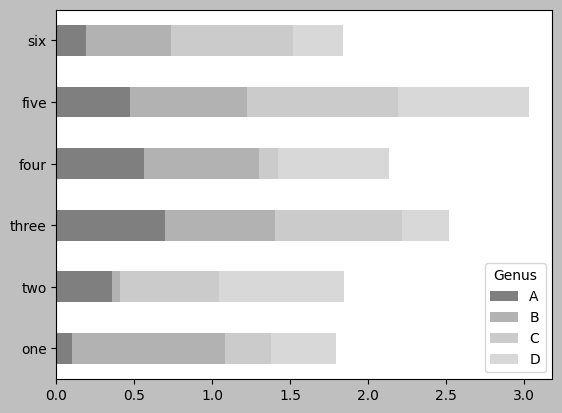

In [7]:
df.plot.barh(stacked=True, alpha=0.5)

### Example: restaurant tipping data

Suppose we want a stacked bar plot showing the percentage of data points for each party size, by day. Load the data with `read_csv` and build a cross-tabulation of day vs. party size. `pandas.crosstab` is a convenient way to compute a frequency table from two DataFrame columns:

In [8]:
tips = pd.read_csv("/Users/bmart231/DS/examples/tips.csv")

tips.head()

,total_bill,tip,smoker,day,time,size
0,16.99,1.01,No,Sun,Dinner,2
1,10.34,1.66,No,Sun,Dinner,3
2,21.01,3.50,No,Sun,Dinner,3
3,23.68,3.31,No,Sun,Dinner,2
4,24.59,3.61,No,Sun,Dinner,4


In [9]:
party_counts = pd.crosstab(tips["day"], tips["size"])

party_counts = party_counts.reindex(index=["Thur", "Fri", "Sat", "Sun"])

party_counts

size,1,2,3,4,5,6
day,,,,,,
Thur,1,48,4,5,1,3
Fri,1,16,1,1,0,0
Sat,2,53,18,13,1,0
Sun,0,39,15,18,3,1


Since there aren't many one- and six-person parties, remove them here.

In [10]:
party_counts = party_counts.loc[:, 2:5]

Then normalize so that each row sums to 1, and make the plot. 

In [11]:
# normalize to sum to 1
party_pcts = party_counts.div(party_counts.sum(axis="columns"), axis="index")

party_pcts

size,2,3,4,5
day,,,,
Thur,0.827586,0.068966,0.086207,0.017241
Fri,0.888889,0.055556,0.055556,0.000000
Sat,0.623529,0.211765,0.152941,0.011765
Sun,0.520000,0.200000,0.240000,0.040000


<Axes: xlabel='day'>

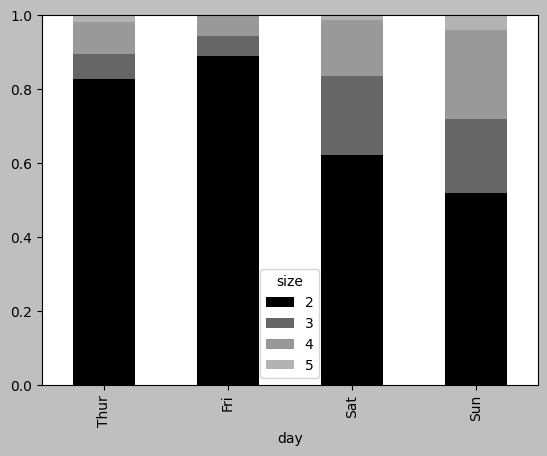

In [12]:
party_pcts.plot.bar(stacked=True)

We can see that party sizes appear to increase on the weekend in this dataset.

With data that requires aggregation or summarization before plotting, `seaborn` can make things much simpler.

In [13]:
import seaborn as sns 

tips["tip_pct"] = tips["tip"] / (tips["total_bill"] - tips["tip"])

tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.063204
1,10.34,1.66,No,Sun,Dinner,3,0.191244
2,21.01,3.50,No,Sun,Dinner,3,0.199886
3,23.68,3.31,No,Sun,Dinner,2,0.162494
4,24.59,3.61,No,Sun,Dinner,4,0.172069


<Axes: xlabel='tip_pct', ylabel='day'>

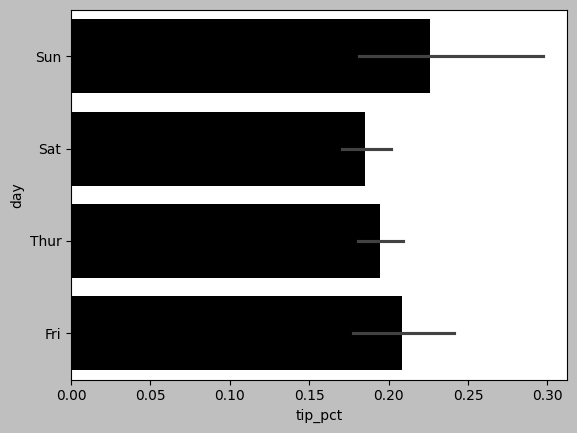

In [14]:
sns.barplot(x="tip_pct", y="day", data=tips, orient="h")

Plotting functions in `seaborn` take a `data` argument, which can be a pandas DataFrame — the other arguments refer to column names. Because there are multiple observations for each value of `day`, the bars show the *average* value of `tip_pct`, and the black lines drawn on the bars represent the 95% confidence interval (computed via bootstrapping).

`seaborn.barplot` has a `hue` option that splits the data by an additional categorical variable:

<Axes: xlabel='tip_pct', ylabel='day'>

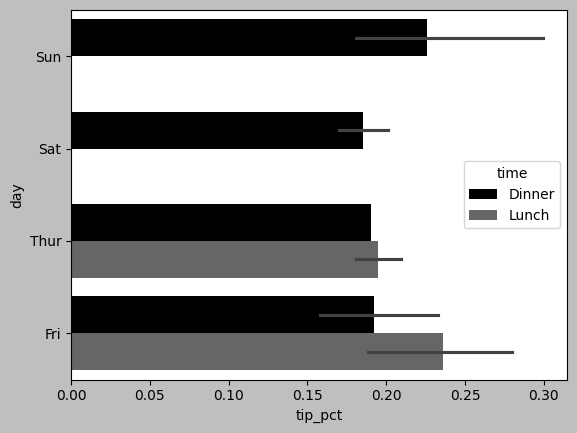

In [15]:
sns.barplot(x="tip_pct", y="day", hue="time", data=tips, orient="h")

`seaborn` automatically changes the aesthetics of matplotlib plots: the default color palette, plot background, and grid line colors. Switch between appearances with `seaborn.set_style()`. Call it *before* creating the plot — it changes the style for plots drawn afterward, not ones already rendered:

<Axes: xlabel='tip_pct', ylabel='day'>

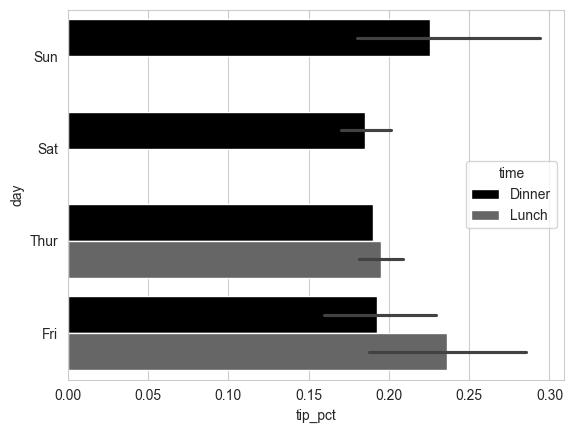

In [16]:
sns.set_style("whitegrid")
sns.barplot(x="tip_pct", y="day", hue="time", data=tips, orient="h")

For a black-and-white print medium, it can be useful to set a greyscale color palette with `seaborn.set_palette()`, called the same way — before plotting:

<Axes: xlabel='tip_pct', ylabel='day'>

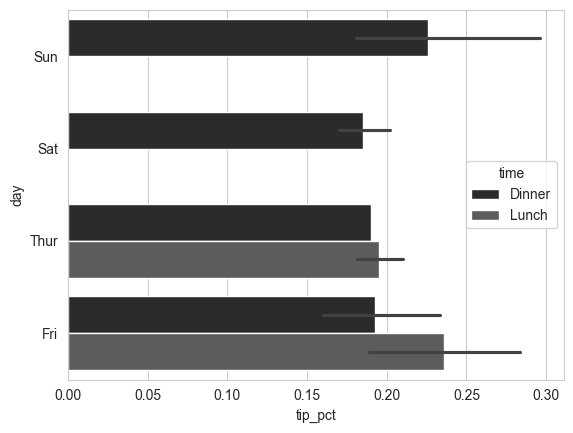

In [17]:
sns.set_palette("Greys_r")
sns.barplot(x="tip_pct", y="day", hue="time", data=tips, orient="h")

> **Note:** `set_style` and `set_palette` are *global* — they affect every plot drawn afterward, in this notebook or script, until changed again. Reset to seaborn's defaults with `sns.set_theme()`, or fully reset to matplotlib's defaults with `sns.reset_orig()`.

## Histograms and Density Plots

A **histogram** is a kind of bar plot giving a discretized display of value frequency: data points are split into evenly spaced bins, and the count of points in each bin is plotted. Using the tipping data, make a histogram of tip percentages with `plot.hist` on the Series:

<Axes: ylabel='Frequency'>

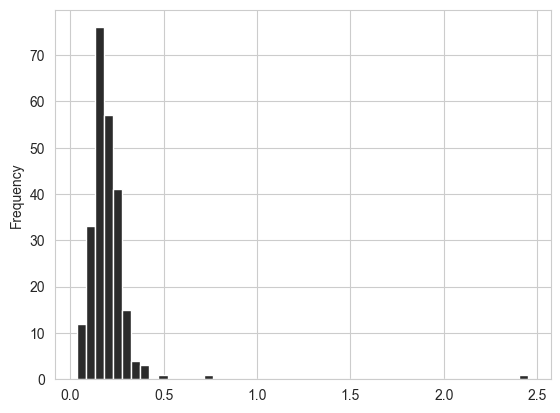

In [18]:
tips["tip_pct"].plot.hist(bins=50)

A related plot type is a **density plot**, formed by computing an estimate of a continuous probability distribution that might have generated the observed data. The usual approach approximates the distribution as a mixture of "kernels" — simpler distributions like the normal distribution — so density plots are also called kernel density estimate (KDE) plots. `plot.density` makes a density plot using the conventional mixture-of-normals estimate.

<Axes: ylabel='Density'>

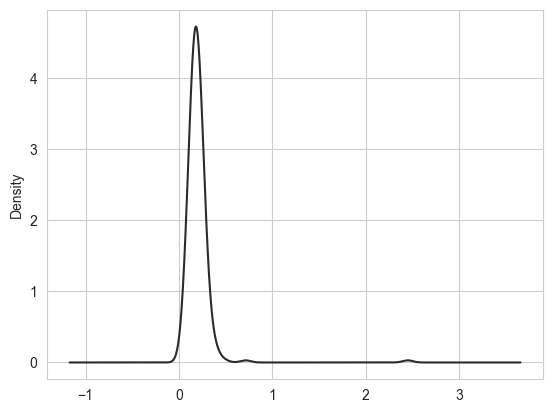

In [19]:
tips["tip_pct"].plot.density()

This kind of plot requires SciPy.

`seaborn` makes histograms and density plots even easier with `histplot`, which can plot both a histogram and a continuous density estimate simultaneously. As an example, consider a bimodal distribution made up of draws from two different normal distributions:

<Axes: ylabel='Count'>

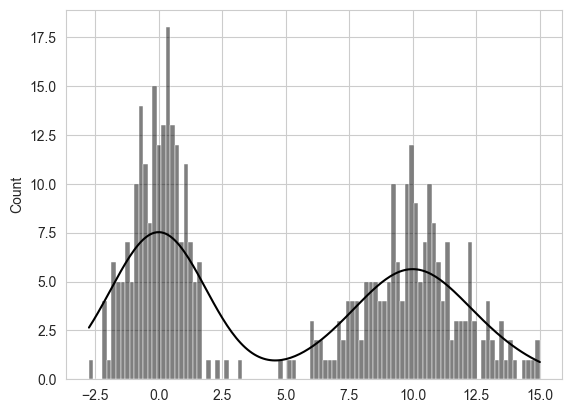

In [20]:
comp1 = np.random.standard_normal(200)

comp2 = 10 + 2 * np.random.standard_normal(200)

values = pd.Series(np.concatenate([comp1, comp2]))

sns.histplot(values, bins=100, color="black", kde=True)

## Scatter or Point Plots

Point plots or scatter plots are useful for examining the relationship between two one-dimensional data series. For example, here we load the `macrodata` dataset from the `statsmodels` project, select a few variables, then compute log differences (a common way to make an economic time series stationary):

In [21]:
macro = pd.read_csv("/Users/bmart231/DS/examples/macrodata.csv")

data = macro[["cpi", "m1", "tbilrate", "unemp"]]

trans_data = np.log(data).diff().dropna()

trans_data.tail()

,cpi,m1,tbilrate,unemp
198,-0.007904,0.045361,-0.396881,0.105361
199,-0.021979,0.066753,-2.277267,0.139762
200,0.002340,0.010286,0.606136,0.160343
201,0.008419,0.037461,-0.200671,0.127339
202,0.008894,0.012202,-0.405465,0.042560


Use seaborn's `regplot` method to make a scatter plot with a fitted linear regression line:

Text(0.5, 1.0, 'Changes in log(m1) versus log(unemp)')

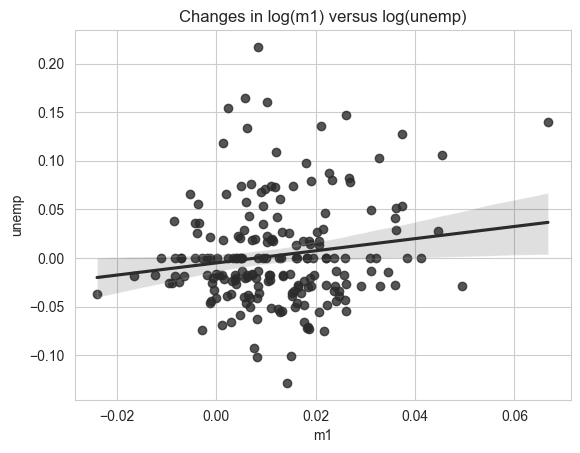

In [22]:
ax = sns.regplot(x="m1", y="unemp", data=trans_data)
ax.set_title("Changes in log(m1) versus log(unemp)")

In exploratory data analysis, it's helpful to look at all the pairwise scatter plots among a group of variables — known as a *pairs plot* or *scatter plot matrix*. `seaborn.pairplot` supports this, placing histograms or density estimates of each variable along the diagonal:

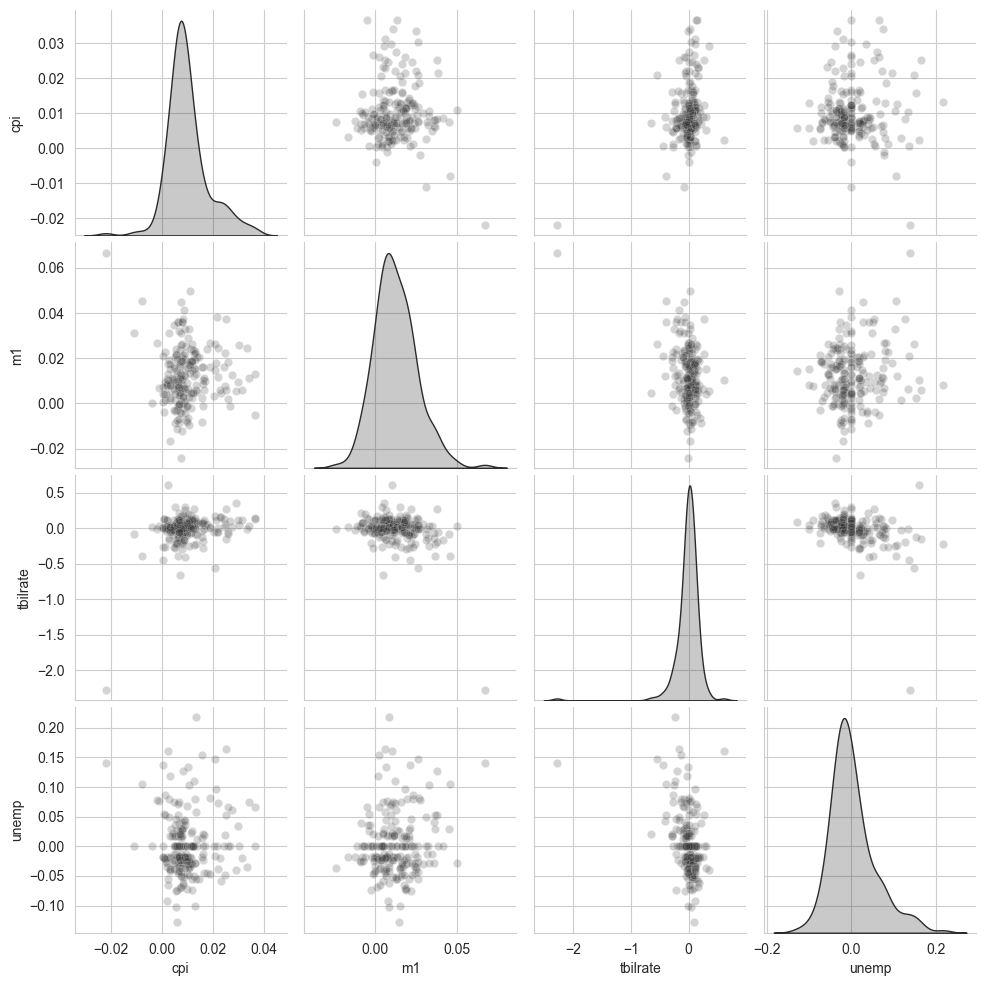

In [23]:
sns.pairplot(trans_data, diag_kind="kde", plot_kws={"alpha": 0.2})

The `plot_kws` argument lets us pass configuration options down to the individual plotting calls on the off-diagonal elements (e.g., `plot_kws={"alpha": 0.2}` above to reduce overplotting). Check the `seaborn.pairplot` docstring for more granular configuration options.

## Facet Grids and Categorical Data

What about datasets with additional grouping dimensions? One way to visualize data with several categorical variables is a **facet grid** — a two-dimensional layout of plots where the data is split across the plots on each axis by the distinct values of a given variable. `seaborn`'s `catplot` function simplifies making many kinds of faceted plots split by categorical variables.

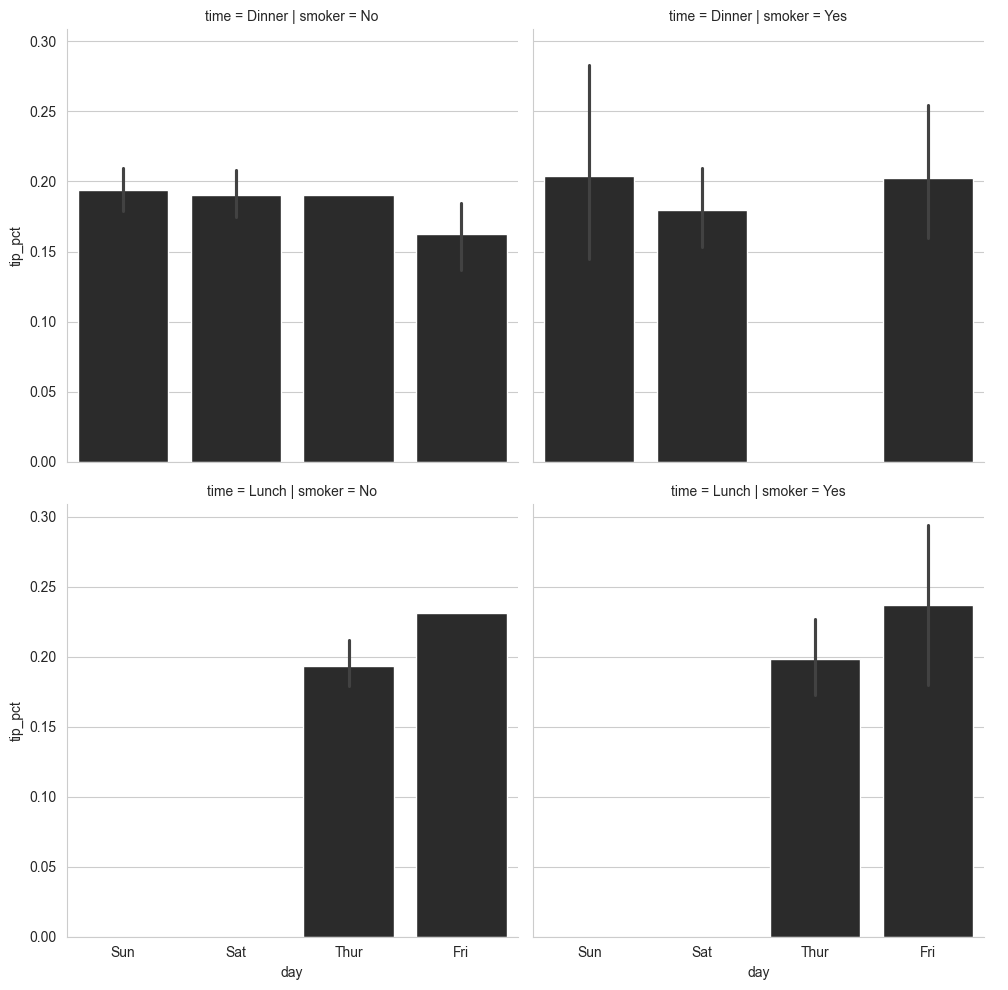

In [24]:
sns.catplot(x="day", y="tip_pct", row="time", col="smoker", kind="bar", data=tips[tips.tip_pct < 1])

`catplot` supports other plot types depending on what you're trying to display. For example, **box plots** (which show the median, quartiles, and outliers) can be a useful visualization type:

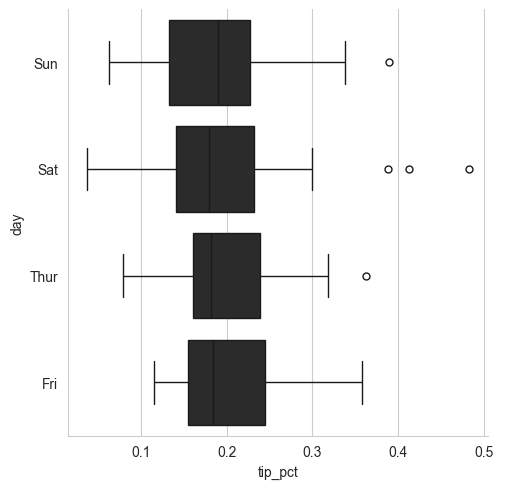

In [25]:
sns.catplot(x="tip_pct", y="day", kind="box", data=tips[tips.tip_pct < 0.5])

## Quick Reference

**pandas `.plot` accessor** — call directly on a `Series`/`DataFrame`, no aggregation needed:

| Method | Produces |
|---|---|
| `.plot()` / `.plot.line()` | Line plot |
| `.plot.bar()` / `.plot.barh()` | Vertical / horizontal bar plot (add `stacked=True` to stack) |
| `.plot.hist(bins=...)` | Histogram |
| `.plot.density()` / `.plot.kde()` | Kernel density estimate |
| `.plot.box()` | Box plot |
| `.plot.area()` | Area plot |
| `.plot.pie()` | Pie plot |
| `.plot.scatter(x=, y=)` | Scatter plot (DataFrame only) |
| `.plot.hexbin(x=, y=)` | Hexbin density plot (DataFrame only) |

**seaborn** — pass a tidy DataFrame via `data=` and refer to columns by name; seaborn handles aggregation and grouping:

| Function | Use for |
|---|---|
| `sns.barplot(x=, y=, hue=, data=)` | Mean (+ CI) of a variable, grouped by category |
| `sns.histplot(data, bins=, kde=)` | Histogram, optionally with a KDE overlay |
| `sns.regplot(x=, y=, data=)` | Scatter plot with a fitted linear regression line |
| `sns.pairplot(data, diag_kind=, plot_kws=)` | Pairwise scatter plot matrix |
| `sns.catplot(x=, y=, row=, col=, kind=, data=)` | Faceted plots split by categorical variables (`kind="bar"`, `"box"`, `"strip"`, `"violin"`, ...) |
| `sns.set_style(...)` / `sns.set_palette(...)` | Global appearance settings — call *before* plotting |
| `sns.set_theme()` / `sns.reset_orig()` | Reset styling to seaborn / matplotlib defaults |

**Rule of thumb, restated:** pandas `.plot` for a quick look at data already shaped the way you want it; seaborn when you need pandas-style aggregation, confidence intervals, or faceting by category baked into the plotting call itself.